For week 5, we used scaling methods and Support Vector regressions on our datasets.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, epsilon=0.2, gamma=0.01))
])

In [26]:
svr_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0


In [27]:
y_pred = svr_model.predict(X_test)

In [28]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.5320
MSE:  0.4270
RMSE: 0.6535
R²:   0.5427


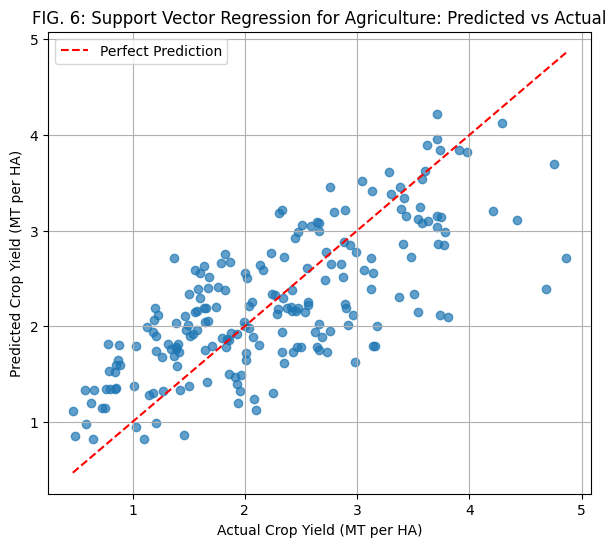

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Crop Yield (MT per HA)")
plt.ylabel("Predicted Crop Yield (MT per HA)")
plt.title("FIG. 6: Support Vector Regression for Agriculture: Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Recreate your pipeline base
base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

# 2. Define a search grid (testing higher C values to fix compression)
param_grid = {
    "svr__C": [0.1, 1, 10, 100, 1000],       # Testing up to 1000 to allow fitting to extremes
    "svr__epsilon": [0.01, 0.05, 0.1, 0.2],  # Controls the width of the margin tube
    "svr__gamma": ["scale", "auto", 0.01, 0.1] # Controls individual data point influence
}

# 3. Run the grid search using Cross-Validation
grid_search = GridSearchCV(
    base_pipeline, 
    param_grid, 
    cv=5, 
    scoring="neg_mean_squared_error", 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# 4. Extract the optimized model
best_svr_model = grid_search.best_estimator_
print("Best Parameters found:", grid_search.best_params_)


Best Parameters found: {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 0.01}


In [12]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


Support Vector Regression Results
--------------------------------
MAE:  0.0845
MSE:  0.0085
RMSE: 0.0923
R²:   -0.6851


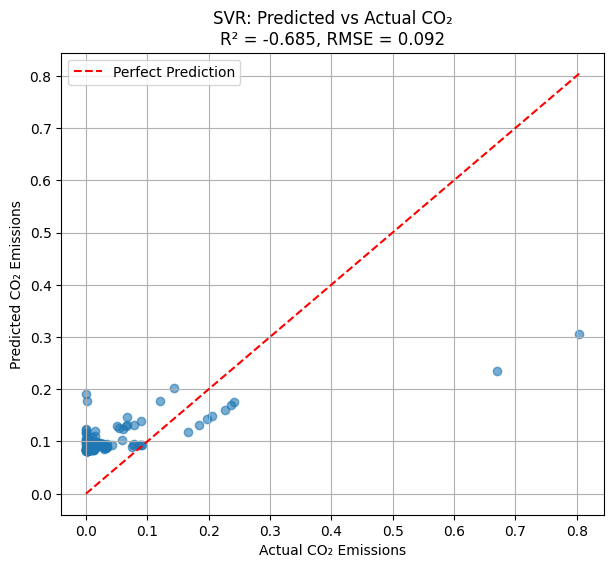

In [13]:
y = clean_numeric_dfCO2["temperature_change_from_co2"]
X = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build SVR model
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
])

# Train model
svr_model.fit(X_train, y_train)

# Predict
y_pred = svr_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Support Vector Regression Results")
print("--------------------------------")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# Plot predictions
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title(f"SVR: Predicted vs Actual CO₂\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.legend()
plt.grid(True)
plt.show()

This does not look like it worked very well. Negative R2.